<div style="background: linear-gradient(135deg, #003262 0%, #0058A4 50%, #008585 100%); padding: 30px; border-radius: 8px; color: white;">

# 🏔️ Nova Scotia Health Zone Population Analysis
### Age Distribution EDA & Population Projection (2026–2030)

</div>

<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**Objective:**
1. Clean and explore the age-sex structure of Nova Scotia's four health zones (2021 Census)
2. Project NS population forward to **2030** using regression on 14 years of actual data (2012–2025)
3. Distribute projections to health zones and visualise by age cohort

**Source Data:**
- `Health Zone population.csv` — 2021 Census of Population, health region profiles (raw)
- `Population_age_and_gender.csv` — NS-level population by 5-yr age band & sex, 2012–2025

**Key Context:** Nova Scotia crossed **1 million in 2022** and reached **1.09 million by 2025** — a 16% increase since 2012, driven by in-migration especially post-2020.

</div>

**Brand Palette:** Nova Scotia Provincial — Deep Blue · Scotia Blue · Sky Blue · Sea Green · Island Teal

---
<div style="border-bottom: 3px solid #003262; padding-bottom: 5px;">

## Section 1 — Data Cleaning & Structure

</div>

<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**🔧 What this cell does — Setting Up the Environment**

This cell loads all the Python libraries we need for the analysis:

| Library | Purpose |
|---|---|
| `pandas` | Data manipulation — loading CSV files, filtering rows, grouping, pivoting |
| `numpy` | Numerical operations — arrays, polynomial fitting, math |
| `matplotlib` | Static chart creation — the backbone of Python plotting |
| `seaborn` | Statistical visualisation — built on matplotlib with better defaults |
| `scipy.stats` | Statistical functions — linear regression for trend lines |
| `plotly` | **Interactive** charts — hover, zoom, pan (the charts you can click on) |

It also defines the **Nova Scotia brand colour palette** — every chart in this notebook uses these official provincial colours for consistency:
- **Deep Blue** `#003262` — backgrounds and primary text
- **Scotia Blue** `#0058A4` — men in pyramids, key data series
- **Sky Blue** `#00AFEF` — highlights and titles
- **Sea Green** `#48B8C7` — women in pyramids, secondary data
- **Island Teal** `#008585` — accent colour
- **Crimson** `#D30731` — projections and alerts

Each health zone gets its own colour so you can track it across all charts.

</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from numpy.polynomial import polynomial as P
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Nova Scotia Brand Palette ─────────────────────────────────────────────────
NS = {
    'deep_blue':    '#003262',
    'scotia_blue':  '#0058A4',
    'sky_blue':     '#00AFEF',
    'sea_green':    '#48B8C7',
    'island_teal':  '#008585',
    'slate_blue':   '#85BACD',
    'flag_blue':    '#0047B6',
    'crimson':      '#D30731',
    'gold':         '#C9A961',
    'white':        '#FFFFFF',
    'light_bg':     '#F0F5FA',
}

ZONE_COLORS = {
    'Western':  NS['deep_blue'],
    'Northern': NS['sea_green'],
    'Eastern':  NS['island_teal'],
    'Central':  NS['sky_blue'],
}

ZONES = ['Western', 'Northern', 'Eastern', 'Central']

# Matplotlib dark theme with NS colours
plt.rcParams.update({
    'figure.facecolor': NS['deep_blue'],
    'axes.facecolor': NS['deep_blue'],
    'text.color': NS['white'],
    'axes.labelcolor': NS['slate_blue'],
    'xtick.color': NS['slate_blue'],
    'ytick.color': NS['slate_blue'],
})

print("Libraries loaded · Nova Scotia brand palette defined")

Libraries loaded · Nova Scotia brand palette defined


<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**🧹 What happens next — Cleaning the Raw Census Data**

The raw Census file from Statistics Canada contains **~347,000 rows** covering every health region in Canada — not just Nova Scotia. We need to:

1. **Filter** to only the 4 Nova Scotia health zones (Western, Northern, Eastern, Central)
2. **Extract** the 21 five-year age bands (e.g., "0 to 4 years", "5 to 9 years" ... "100 years and over")
3. **Remove** summary rows like "Total population" or "0 to 14 years" which would double-count
4. **Remove** percentage rows — the Census includes both raw counts AND percentages; we only want counts (filtered by keeping values > 40)
5. **Build** a clean dataframe with columns: `Health Zone`, `Health Zone Name`, `Age Group`, `Total`, `Men`, `Women`
6. **Add** a numeric midpoint (e.g., "20 to 24 years" → 22) so we can sort and plot age bands in order

The function `age_midpoint()` converts text labels like "40 to 44 years" into the number 42 — the centre of that age range. This is essential for creating smooth line charts later.

The result is **84 clean rows** (21 age bands × 4 zones) — a massive reduction from 347K rows.

</div>

In [2]:
# ── Load raw Census file ──────────────────────────────────────────────────────
raw = pd.read_csv('./data/Health Zone population.csv', low_memory=False, encoding='latin1')

# Filter to NS health zones only
ns = raw[raw['GEO_NAME'].str.contains(
    'Zone.*Western|Zone.*Northern|Zone.*Eastern|Zone.*Central',
    na=False, case=False
)].copy()

print(f"Raw file: {raw.shape[0]:,} rows")
print(f"NS zone rows: {len(ns):,}")

# ── Extract 5-year age bands only (exclude summary groups) ────────────────────
SINGLE_BANDS = [
    '0 to 4 years','5 to 9 years','10 to 14 years','15 to 19 years',
    '20 to 24 years','25 to 29 years','30 to 34 years','35 to 39 years',
    '40 to 44 years','45 to 49 years','50 to 54 years','55 to 59 years',
    '60 to 64 years','65 to 69 years','70 to 74 years','75 to 79 years',
    '80 to 84 years','85 to 89 years','90 to 94 years','95 to 99 years',
    '100 years and over'
]

age = ns[ns['CHARACTERISTIC_NAME'].str.strip().isin(SINGLE_BANDS)].copy()
age = age[age['C1_COUNT_TOTAL'] > 40]  # exclude percentage rows

# ── Build clean dataframe ─────────────────────────────────────────────────────
df = pd.DataFrame({
    'CENSUS_YEAR': 2021,
    'Health Zone':      age['GEO_NAME'].str.extract(r'(Zone \d)')[0].values,
    'Health Zone Name': age['GEO_NAME'].str.extract(r'- (.+)')[0].str.strip().values,
    'Age Group':        age['CHARACTERISTIC_NAME'].str.strip().values,
    'Total':            age['C1_COUNT_TOTAL'].astype(int).values,
    'Men':              age['C2_COUNT_MEN+'].astype(int).values,
    'Women':            age['C3_COUNT_WOMEN+'].astype(int).values,
})

# ── Add numeric midpoint for sorting & plotting ──────────────────────────────
def age_midpoint(label):
    if '100' in label:
        return 102
    parts = label.replace(' years', '').replace(' and over', '').split(' to ')
    return (int(parts[0]) + int(parts[1])) / 2

df['AgeMid'] = df['Age Group'].apply(age_midpoint)
df = df.sort_values(['Health Zone', 'AgeMid']).reset_index(drop=True)

print(f"\nClean dataframe: {df.shape}")
print(f"Zones: {df['Health Zone Name'].unique()}")
print(f"Age groups: {df['Age Group'].nunique()}")
df.head(10)

Raw file: 347,292 rows
NS zone rows: 10,524

Clean dataframe: (84, 8)
Zones: ['Western' 'Northern' 'Eastern' 'Central']
Age groups: 21


,CENSUS_YEAR,Health Zone,Health Zone Name,Age Group,Total,Men,Women,AgeMid
0,2021,Zone 1,Western,0 to 4 years,7475,3820,3655,2.0
1,2021,Zone 1,Western,5 to 9 years,8900,4555,4340,7.0
2,2021,Zone 1,Western,10 to 14 years,9400,4880,4520,12.0
3,2021,Zone 1,Western,15 to 19 years,9305,4800,4505,17.0
4,2021,Zone 1,Western,20 to 24 years,9280,4880,4400,22.0
5,2021,Zone 1,Western,25 to 29 years,9005,4525,4480,27.0
6,2021,Zone 1,Western,30 to 34 years,9760,4745,5015,32.0
7,2021,Zone 1,Western,35 to 39 years,10135,4930,5210,37.0
8,2021,Zone 1,Western,40 to 44 years,10345,4910,5430,42.0
9,2021,Zone 1,Western,45 to 49 years,11630,5630,5995,47.0


<div style="border-left: 4px solid #48B8C7; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**👀 Quick Check — Last 10 Rows**

We display the last 10 rows to verify the data looks correct. You should see Zone 4 (Central) with the oldest age bands (90–94, 95–99, 100+). If the numbers look reasonable (e.g., only ~95 people aged 100+ in Central), the cleaning worked.

</div>

In [3]:
df.tail(10)

,CENSUS_YEAR,Health Zone,Health Zone Name,Age Group,Total,Men,Women,AgeMid
74,2021,Zone 4,Central,55 to 59 years,33900,16555,17345,57.0
75,2021,Zone 4,Central,60 to 64 years,31500,15170,16335,62.0
76,2021,Zone 4,Central,65 to 69 years,26445,12305,14140,67.0
77,2021,Zone 4,Central,70 to 74 years,22485,10385,12095,72.0
78,2021,Zone 4,Central,75 to 79 years,14835,6800,8035,77.0
79,2021,Zone 4,Central,80 to 84 years,9230,3945,5290,82.0
80,2021,Zone 4,Central,85 to 89 years,5455,2170,3290,87.0
81,2021,Zone 4,Central,90 to 94 years,2240,715,1525,92.0
82,2021,Zone 4,Central,95 to 99 years,650,110,535,97.0
83,2021,Zone 4,Central,100 years and over,95,20,75,102.0


<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**📊 Zone Population Summary**

This cell calculates the total population per health zone by summing all 21 age bands. It also computes:

- **Sex Ratio (M/F):** How many men per woman. Values below 1.0 mean more women (common due to female longevity). Values close to 1.0 suggest a younger, more balanced population.
- **Pct of NS:** Each zone's share of the provincial total. Central (Halifax metro) typically holds ~47% of NS population.

This gives us the "big picture" before diving into age-specific analysis.

</div>

In [4]:
# ── Zone totals ───────────────────────────────────────────────────────────────
zone_totals = df.groupby('Health Zone Name')[['Total','Men','Women']].sum()
zone_totals['Sex Ratio (M/F)'] = (zone_totals['Men'] / zone_totals['Women']).round(3)
zone_totals['Pct of NS'] = (zone_totals['Total'] / zone_totals['Total'].sum() * 100).round(1)

print("Population by Health Zone — 2021 Census\n")
print(zone_totals.to_string())
print(f"\nNS Total: {zone_totals['Total'].sum():,}")

Population by Health Zone — 2021 Census

                   Total     Men   Women  Sex Ratio (M/F)  Pct of NS
Health Zone Name                                                    
Central           461290  224720  236570            0.950       47.6
Eastern           159515   77040   82480            0.934       16.5
Northern          149580   72950   76660            0.952       15.4
Western           198980   97005  101960            0.951       20.5

NS Total: 969,365


---
<div style="border-bottom: 3px solid #003262; padding-bottom: 5px;">

## Section 2 — EDA: Age Distribution Across Health Zones

</div>

<div style="border-left: 4px solid #48B8C7; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**🏛️ Population Pyramids — What Am I Looking At?**

A **population pyramid** is a pair of horizontal bar charts placed back-to-back:
- **Left side** = Men (in blue)
- **Right side** = Women (in green)
- **Y-axis** = Age bands from youngest (bottom) to oldest (top)
- **X-axis** = Number of people

**How to read them:**
- A **wide base** (big bars at bottom) = lots of children = young, growing population
- A **bulging middle** (big bars in the 40–60 range) = large working-age cohort
- A **top-heavy shape** (wider bars at top than bottom) = aging population
- **Women extending further right** at older ages = women live longer (very common)

**What to look for in NS:**
- Central will look different from the rural zones — more 20-somethings (students, young workers)
- Rural zones (Western, Northern, Eastern) will bulge at 55–70 — the baby boom cohort aging in place
- The 80+ bars tell you about long-term care demand

The **interactive version** (Plotly) lets you hover over any bar to see exact counts. The **static version** (matplotlib) is for exporting to PDF/reports.

</div>

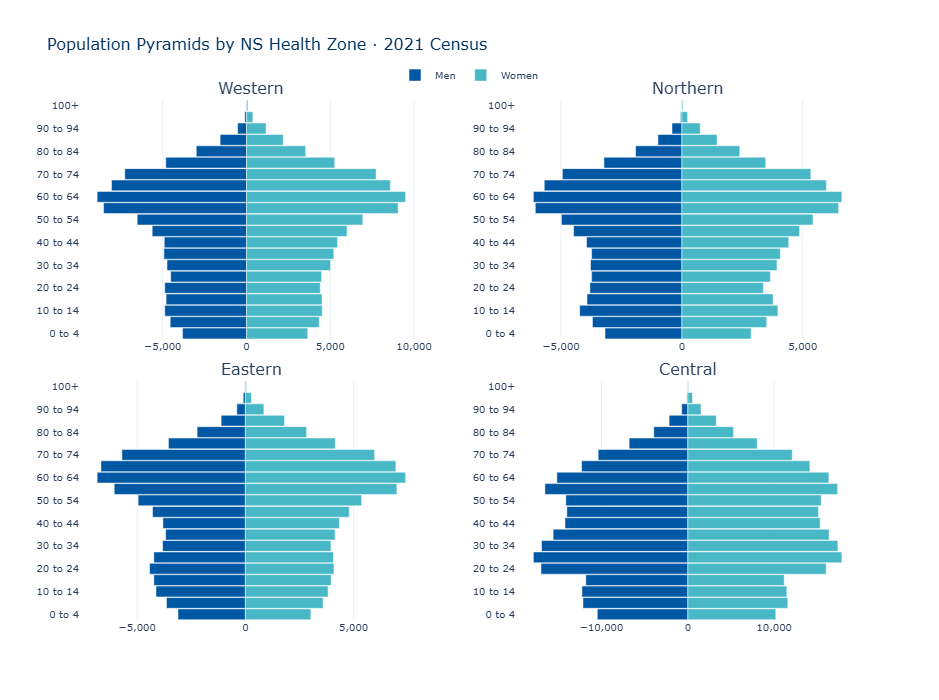

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# INTERACTIVE POPULATION PYRAMIDS — Plotly
# ══════════════════════════════════════════════════════════════════════════════

zones = ['Western', 'Northern', 'Eastern', 'Central']

fig = make_subplots(rows=2, cols=2, subplot_titles=zones,
                    horizontal_spacing=0.12, vertical_spacing=0.08)

for idx, zone in enumerate(zones):
    row, col = idx // 2 + 1, idx % 2 + 1
    zdf = df[df['Health Zone Name'] == zone].sort_values('AgeMid')
    labels = zdf['Age Group'].str.replace(' years', '').str.replace(' and over', '+').values
    
    fig.add_trace(go.Bar(
        y=labels, x=-zdf['Men'].values, orientation='h',
        name='Men' if idx == 0 else None, showlegend=(idx == 0),
        marker_color=NS['scotia_blue'],
        hovertemplate='%{y}: %{customdata:,} men<extra></extra>',
        customdata=zdf['Men'].values,
    ), row=row, col=col)
    
    fig.add_trace(go.Bar(
        y=labels, x=zdf['Women'].values, orientation='h',
        name='Women' if idx == 0 else None, showlegend=(idx == 0),
        marker_color=NS['sea_green'],
        hovertemplate='%{y}: %{x:,} women<extra></extra>',
    ), row=row, col=col)

fig.update_layout(
    title=dict(text='Population Pyramids by NS Health Zone · 2021 Census',
               font=dict(size=16, color=NS['deep_blue'])),
    barmode='overlay', bargap=0.05,
    height=700, template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
    font=dict(size=10),
)
fig.update_xaxes(tickformat=',d')
fig.show()

<div style="border-left: 4px solid #85BACD; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**📸 Static Version (for Export)**

This is the same pyramid data rendered with matplotlib instead of Plotly. Use this version when you need to save a PNG image for a report, presentation, or PDF — Plotly charts are interactive but don't export as easily.

</div>

<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**📊 Age Structure Comparison — The Big Picture**

This chart groups all 21 age bands into just **4 broad categories** and shows each zone's mix as a stacked bar:

| Category | Ages | What it represents |
|---|---|---|
| **Children (0–14)** | 0–14 | Future workforce, school demand |
| **Youth (15–24)** | 15–24 | Education, entry-level employment |
| **Working Age (25–64)** | 25–64 | Tax base, economic productivity |
| **Seniors (65+)** | 65+ | Healthcare demand, pension draw |

**What to look for:**
- Which zone has the **highest seniors share**? That zone faces the greatest healthcare burden.
- Which zone has the **biggest working-age share**? That's the economic engine.
- Are children a **smaller** slice than seniors? If yes, the population is aging — fewer young people entering the workforce than old people leaving it.

Hover over any segment to see the exact percentage.

</div>

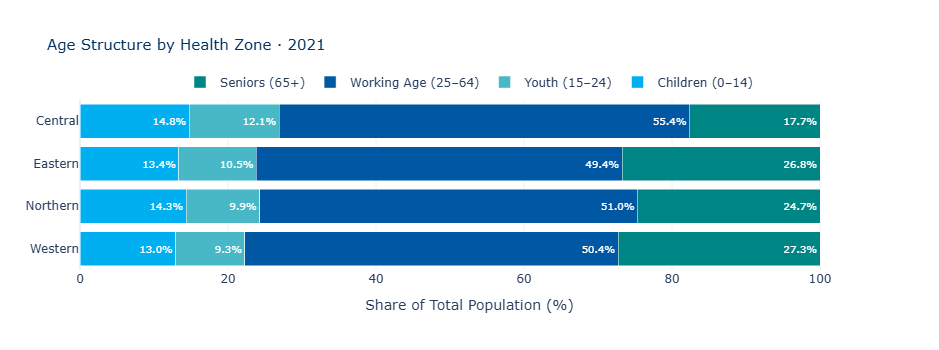

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# INTERACTIVE AGE STRUCTURE — Plotly stacked bars
# ══════════════════════════════════════════════════════════════════════════════

def broad_band(mid):
    if mid < 15:   return 'Children (0–14)'
    elif mid < 25: return 'Youth (15–24)'
    elif mid < 65: return 'Working Age (25–64)'
    else:          return 'Seniors (65+)'

df['BroadBand'] = df['AgeMid'].apply(broad_band)
broad_order = ['Children (0–14)', 'Youth (15–24)', 'Working Age (25–64)', 'Seniors (65+)']
broad_colors_map = {
    'Children (0–14)': NS['sky_blue'],
    'Youth (15–24)': NS['sea_green'],
    'Working Age (25–64)': NS['scotia_blue'],
    'Seniors (65+)': NS['island_teal'],
}

pct = df.groupby(['Health Zone Name', 'BroadBand'])['Total'].sum().unstack(fill_value=0)[broad_order]
pct_norm = pct.div(pct.sum(axis=1), axis=0) * 100

fig = go.Figure()
for band in broad_order:
    fig.add_trace(go.Bar(
        y=zones, x=pct_norm.reindex(zones)[band],
        name=band, orientation='h',
        marker_color=broad_colors_map[band],
        text=pct_norm.reindex(zones)[band].apply(lambda v: f'{v:.1f}%'),
        textposition='inside', textfont=dict(size=10, color='white'),
    ))

fig.update_layout(
    barmode='stack',
    title=dict(text='Age Structure by Health Zone · 2021', font=dict(size=15, color=NS['deep_blue'])),
    xaxis_title='Share of Total Population (%)',
    template='plotly_white', height=350,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='center', x=0.5),
)
fig.show()

<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**⚖️ Dependency Ratios — Who Supports Whom?**

A **dependency ratio** asks: *for every 100 working-age adults (15–64), how many dependents (children or seniors) are there?*

| Metric | Formula | What it means |
|---|---|---|
| **Youth Dependency** | (0–14) ÷ (15–64) × 100 | School/childcare demand per worker |
| **Old-Age Dependency** | (65+) ÷ (15–64) × 100 | Healthcare/pension demand per worker |
| **Total Dependency** | Both combined | Overall burden on working population |
| **Aging Index** | (65+) ÷ (0–14) × 100 | Seniors per 100 children |

**Interpreting the Aging Index:**
- **Below 100:** More children than seniors — population is "young"
- **Exactly 100:** Equal numbers — tipping point
- **Above 100:** More seniors than children — population is "aging"
- **Above 200:** Twice as many seniors as children — severe aging

If a zone has a Total Dependency Ratio of 70, it means every 100 workers support 70 dependents. Higher ratios = greater strain on services and tax base.

</div>

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# DEPENDENCY RATIOS & AGING METRICS
# ══════════════════════════════════════════════════════════════════════════════

dep = df.copy()
dep['DepGroup'] = dep['AgeMid'].apply(
    lambda m: 'young' if m < 15 else ('old' if m >= 65 else 'working'))

dep_agg = dep.groupby(['Health Zone Name', 'DepGroup'])['Total'].sum().unstack(fill_value=0)
dep_agg['Youth Dep. Ratio']  = (dep_agg['young'] / dep_agg['working'] * 100).round(1)
dep_agg['Old-Age Dep. Ratio'] = (dep_agg['old']   / dep_agg['working'] * 100).round(1)
dep_agg['Total Dep. Ratio']   = ((dep_agg['young'] + dep_agg['old']) / dep_agg['working'] * 100).round(1)
dep_agg['Aging Index']         = (dep_agg['old'] / dep_agg['young'] * 100).round(1)

print("Dependency Ratios (per 100 working-age 15–64) & Aging Index — 2021\n")
print(dep_agg[['Youth Dep. Ratio', 'Old-Age Dep. Ratio', 'Total Dep. Ratio', 'Aging Index']].to_string())
print("\nAging Index > 100 → more seniors than children")

Dependency Ratios (per 100 working-age 15–64) & Aging Index — 2021

DepGroup          Youth Dep. Ratio  Old-Age Dep. Ratio  Total Dep. Ratio  Aging Index
Health Zone Name                                                                     
Central                       21.9                26.1              48.0        119.5
Eastern                       22.3                44.7              67.0        200.2
Northern                      23.5                40.5              64.0        171.9
Western                       21.7                45.7              67.3        210.7

Aging Index > 100 → more seniors than children


<div style="border-left: 4px solid #48B8C7; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**📈 Age Distribution Curves — Comparing Zone Shapes**

Each subplot shows one zone's population as a **percentage curve** by age:
- The **x-axis** is age (midpoint of each 5-year band)
- The **y-axis** is what percentage of that zone's total population falls in that age band
- The **shaded area** under the curve emphasises where the population mass sits
- The **peak annotation** marks the single most populous age band

**Why percentages instead of raw counts?**
Because Central has 461K people and Northern has 150K — raw counts would make Central's bars dwarf everything else. Percentages let us compare the *shape* of the age distribution regardless of zone size.

**What to look for:**
- Does the peak fall in the 50s–60s (aging) or the 20s–30s (young)?
- Is the curve **right-skewed** (more old people) or **left-skewed** (more young people)?
- How steep is the drop-off after 70? A gradual decline means many people surviving into old age.

</div>

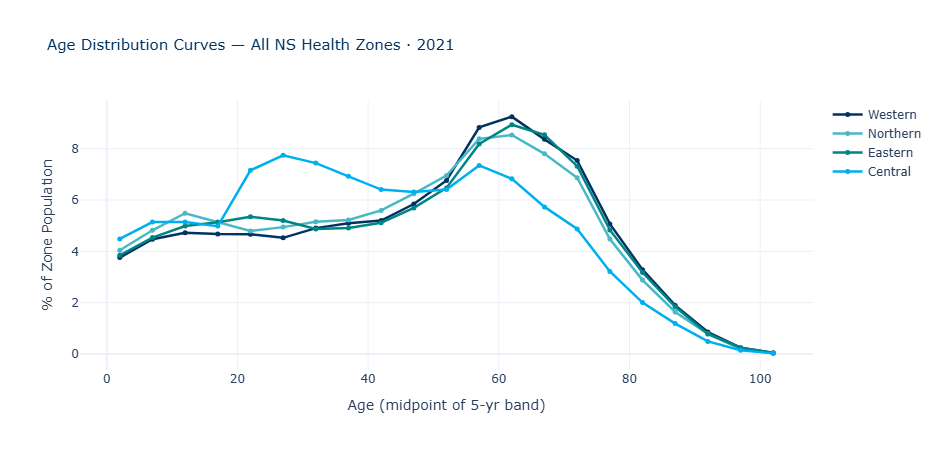

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# INTERACTIVE AGE DISTRIBUTION OVERLAY — Plotly
# ══════════════════════════════════════════════════════════════════════════════

fig = go.Figure()
for zone in zones:
    zdf = df[df['Health Zone Name'] == zone].sort_values('AgeMid')
    pct_share = zdf['Total'] / zdf['Total'].sum() * 100
    fig.add_trace(go.Scatter(
        x=zdf['AgeMid'], y=pct_share,
        mode='lines+markers', name=zone,
        line=dict(color=ZONE_COLORS[zone], width=2.5),
        marker=dict(size=5),
        hovertemplate=f'{zone}<br>Age %{{x:.0f}}: %{{y:.2f}}%<extra></extra>',
    ))

fig.update_layout(
    title=dict(text='Age Distribution Curves — All NS Health Zones · 2021',
               font=dict(size=15, color=NS['deep_blue'])),
    xaxis_title='Age (midpoint of 5-yr band)',
    yaxis_title='% of Zone Population',
    template='plotly_white', height=450,
    hovermode='x unified',
)
fig.show()

---
<div style="border-bottom: 3px solid #003262; padding-bottom: 5px;">

## Section 3 — Population Projection (2026–2030)

</div>

<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**Approach: Regression on 14 Years of Actual Data**

Nova Scotia grew from **943K (2012) to 1.09M (2025)** — a 16% increase driven by in-migration, especially post-2020.

We use `Population_age_and_gender.csv` (2012–2025) to:
1. Fit **linear** and **polynomial (deg 2)** trends per age cohort
2. Extrapolate to **2026–2030**
3. Distribute to zones using **2021 Census zone shares** as weights

**Age Cohorts:** 0–9, 10–19, 20–29, 30–39, 40–49, 50–59, 60–69, 70–79, 80–89, 90–99, 100+

</div>

<div style="border-left: 4px solid #D30731; padding: 10px 15px; margin: 10px 0; background-color: rgba(211,7,49,0.04); border-radius: 4px;">

⚠️ **Assumptions & Limitations**

- **NS-level only** — no zone-specific time series available; zone distribution uses static 2021 Census shares
- **Polynomial (deg 2)** captures post-2020 migration acceleration but can overshoot beyond 2030
- **No migration modelling** at zone level — Central (Halifax) is likely gaining a disproportionate share
- Treat 2030 values as a **scenario**, not a point forecast

</div>

<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**📥 Loading the Population Time Series**

This is a **different file** from the Census. While the Census gives us a single detailed snapshot (2021, by zone), this file gives us **14 years of NS-level totals** (2012–2025) by 5-year age band and sex.

**Why do we need this?** To project the future, we need to see the past trend. One year (2021) tells us nothing about growth or decline. Fourteen years tell us:
- NS was **shrinking** from 2012–2015 (losing people)
- Growth **restarted** around 2016 (immigration policy changes)
- Growth **accelerated dramatically** post-2020 (international migration boom)

We then **aggregate** the 21 five-year bands into **11 ten-year cohorts** (0–9, 10–19, 20–29 ... 90–99, 100+) to match the projection granularity we need.

The `FIVEYR_TO_COHORT` dictionary maps each 5-year band to its parent 10-year cohort (e.g., "20 to 24 years" + "25 to 29 years" → "20 to 29").

</div>

In [11]:
# ── Load NS-level population time series (2012–2025) ──────────────────────────
ns_ts = pd.read_csv('./clean/Population age and gender.csv')
ns_ts['Age_Group'] = ns_ts['Age_Group'].str.replace('100 years and older', '100 years and over')

print(f"NS Time Series: {ns_ts.shape} — Years {ns_ts['Year'].min()}–{ns_ts['Year'].max()}")

# ── Map 5-yr bands → 10-yr cohorts ───────────────────────────────────────────
FIVEYR_TO_COHORT = {
    '0 to 4 years': '0 to 9',    '5 to 9 years': '0 to 9',
    '10 to 14 years': '10 to 19', '15 to 19 years': '10 to 19',
    '20 to 24 years': '20 to 29', '25 to 29 years': '20 to 29',
    '30 to 34 years': '30 to 39', '35 to 39 years': '30 to 39',
    '40 to 44 years': '40 to 49', '45 to 49 years': '40 to 49',
    '50 to 54 years': '50 to 59', '55 to 59 years': '50 to 59',
    '60 to 64 years': '60 to 69', '65 to 69 years': '60 to 69',
    '70 to 74 years': '70 to 79', '75 to 79 years': '70 to 79',
    '80 to 84 years': '80 to 89', '85 to 89 years': '80 to 89',
    '90 to 94 years': '90 to 99', '95 to 99 years': '90 to 99',
    '100 years and over': '100+',
}

ns_ts['Cohort'] = ns_ts['Age_Group'].map(FIVEYR_TO_COHORT)
cohort_ts = ns_ts.groupby(['Year', 'Cohort'])['Population'].sum().reset_index()

COHORT_ORDER = ['0 to 9','10 to 19','20 to 29','30 to 39','40 to 49',
                '50 to 59','60 to 69','70 to 79','80 to 89','90 to 99','100+']

ns_total = ns_ts.groupby('Year')['Population'].sum().reset_index()
ns_total.columns = ['Year', 'NS_Total']

print(f"\nNS Population Trend:")
for _, r in ns_total.iterrows():
    print(f"  {int(r['Year'])}: {int(r['NS_Total']):>10,}")

NS Time Series: (588, 4) — Years 2012–2025

NS Population Trend:
  2012:    943,163
  2013:    939,808
  2014:    937,768
  2015:    937,419
  2016:    942,984
  2017:    952,159
  2018:    962,072
  2019:    975,799
  2020:    989,168
  2021:    999,908
  2022:  1,024,034
  2023:  1,053,005
  2024:  1,082,769
  2025:  1,093,245


<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**📉 NS Total Population Projection — Two Models Compared**

This chart shows the actual NS population (dots) and two forecast lines:

| Model | How it works | Strengths | Weaknesses |
|---|---|---|---|
| **Linear** (dashed) | Draws a straight line through the data | Simple, easy to interpret | Misses the post-2020 acceleration |
| **Polynomial (deg 2)** (solid red) | Fits a curve that can bend | Captures accelerating growth | Can overshoot if trend slows |

**R²** (shown in legend) measures how well the model fits historical data — closer to 1.0 = better fit.

The **shaded region** (2026–2030) is the forecast zone. Numbers in this region are *estimates*, not observations.

**Key question:** Will NS keep accelerating (polynomial is right) or will growth slow down (linear is safer)? The truth is probably somewhere in between — treat the polynomial as an *optimistic scenario* and linear as a *conservative floor*.

</div>

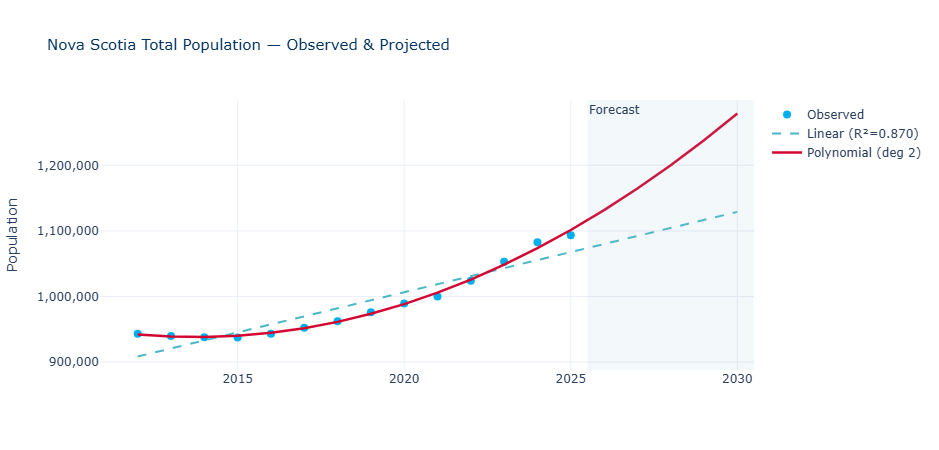


2025 (observed):  1,093,245
2028 (poly):      1,200,239
2030 (poly):      1,279,076


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# INTERACTIVE NS TOTAL — Linear vs Polynomial
# ══════════════════════════════════════════════════════════════════════════════

all_years = np.arange(2012, 2031)
x = ns_total['Year'].values
y = ns_total['NS_Total'].values

slope, intercept, r_lin, _, _ = stats.linregress(x, y)
coeffs_2 = np.polyfit(x, y, 2)

fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=y, mode='markers', name='Observed',
              marker=dict(color=NS['sky_blue'], size=8)))
fig.add_trace(go.Scatter(x=all_years, y=slope*all_years+intercept,
              mode='lines', name=f'Linear (R²={r_lin**2:.3f})',
              line=dict(color=NS['sea_green'], dash='dash')))
fig.add_trace(go.Scatter(x=all_years, y=np.polyval(coeffs_2, all_years),
              mode='lines', name='Polynomial (deg 2)',
              line=dict(color=NS['crimson'], width=2.5)))
fig.add_vrect(x0=2025.5, x1=2030.5, fillcolor=NS['slate_blue'], opacity=0.1,
              line_width=0, annotation_text='Forecast', annotation_position='top left')

fig.update_layout(
    title=dict(text='Nova Scotia Total Population — Observed & Projected',
               font=dict(size=15, color=NS['deep_blue'])),
    yaxis_title='Population', yaxis_tickformat=',',
    template='plotly_white', height=450, hovermode='x unified',
)
fig.show()

print(f"\n2025 (observed): {int(y[-1]):>10,}")
print(f"2028 (poly):     {int(np.polyval(coeffs_2, 2028)):>10,}")
print(f"2030 (poly):     {int(np.polyval(coeffs_2, 2030)):>10,}")

<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**⚙️ Cohort Projection Engine — How Each Age Group Is Forecast**

This cell runs the same polynomial regression **separately for each of the 11 age cohorts**. Why separately?

Because different age groups grow at different rates:
- **20–29** might be surging (immigration)
- **60–69** might be growing fast (baby boomers aging into this band)
- **0–9** might be declining (fewer births)

For each cohort, we:
1. Fit a polynomial (degree 2) curve to 14 years of data
2. Extrapolate that curve 5 years forward (2026–2030)
3. Store the R² (fit quality) and annual trend (+ or − people per year)
4. Use `max(0, ...)` to prevent any cohort from going negative (can't have negative people!)

The summary at the bottom sums all cohorts to show the projected NS total — this should roughly match the NS-total projection from the previous cell.

</div>

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# PROJECTION BY 10-YEAR AGE COHORT
# ══════════════════════════════════════════════════════════════════════════════

cohort_proj = []
for cohort in COHORT_ORDER:
    bts = cohort_ts[cohort_ts['Cohort'] == cohort].sort_values('Year')
    if len(bts) < 5: continue
    bx, by = bts['Year'].values, bts['Population'].values
    c2 = np.polyfit(bx, by, 2)
    sl, ic, r, _, _ = stats.linregress(bx, by)
    
    for _, row in bts.iterrows():
        cohort_proj.append({'Year': int(row['Year']), 'Cohort': cohort,
            'Pop_Poly': int(row['Population']), 'R2': round(r**2,3),
            'Trend': int(sl), 'Source': 'Observed'})
    for yr in range(2026, 2031):
        cohort_proj.append({'Year': yr, 'Cohort': cohort,
            'Pop_Poly': max(0, int(np.polyval(c2, yr))), 'R2': round(r**2,3),
            'Trend': int(sl), 'Source': 'Projected'})

proj = pd.DataFrame(cohort_proj)
ns_proj_summary = proj.drop_duplicates(['Year','Cohort']).groupby('Year')['Pop_Poly'].sum()
print("NS Total (polynomial sum):")
for yr, val in ns_proj_summary.items():
    tag = "✓" if yr <= 2025 else "→"
    print(f"  {yr} {tag} {int(val):>10,}")

NS Total (polynomial sum):
  2012 ✓    943,163
  2013 ✓    939,808
  2014 ✓    937,768
  2015 ✓    937,419
  2016 ✓    942,984
  2017 ✓    952,159
  2018 ✓    962,072
  2019 ✓    975,799
  2020 ✓    989,168
  2021 ✓    999,908
  2022 ✓  1,024,034
  2023 ✓  1,053,005
  2024 ✓  1,082,769
  2025 ✓  1,093,245
  2026 →  1,131,745
  2027 →  1,164,697
  2028 →  1,200,234
  2029 →  1,238,358
  2030 →  1,279,072


<div style="border-left: 4px solid #48B8C7; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**📊 Cohort Projection Facets — 11 Charts at Once**

Each small chart shows one age cohort's history (2012–2025, coloured dots/line) and forecast (2026–2030, red dotted line). This is a **small multiples** layout — comparing the same chart type across categories.

**How to read each subplot:**
- **Dots** = actual observed population for that cohort
- **Solid coloured line** = trend through observed data
- **Red dotted line** = projected future (polynomial extrapolation)
- **Arrow + number** in top-left = annual change and R² fit quality
- **↑ 2,500/yr R²=0.95** means this cohort is growing by ~2,500 people per year and the model fits 95% of the historical data

**What to look for:**
- Which cohorts show **↑** (growing) vs **↓** (shrinking)?
- Are the senior cohorts (60–69, 70–79) growing fastest? If yes, healthcare demand will surge.
- Is the red projection line bending upward sharply? That's the polynomial capturing acceleration.

</div>

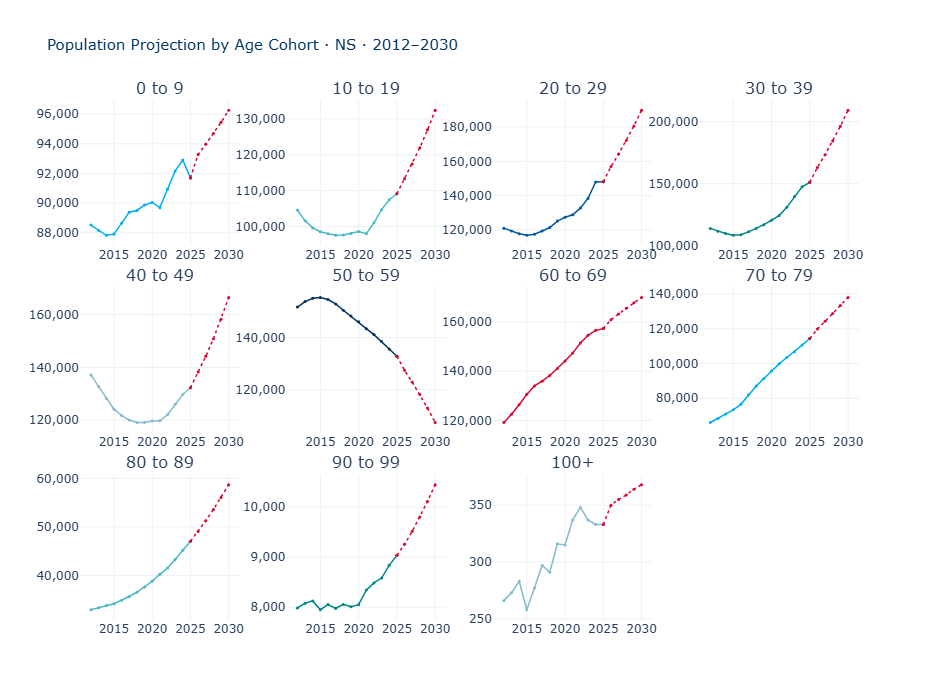

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# INTERACTIVE COHORT PROJECTION FACETS — Plotly
# ══════════════════════════════════════════════════════════════════════════════

cohort_colors = [NS['sky_blue'], NS['sea_green'], NS['scotia_blue'], NS['island_teal'],
                 NS['slate_blue'], NS['deep_blue'], NS['crimson'], NS['sky_blue'],
                 NS['sea_green'], NS['island_teal'], NS['slate_blue']]

fig = make_subplots(rows=3, cols=4, subplot_titles=COHORT_ORDER,
                    horizontal_spacing=0.06, vertical_spacing=0.08)

for i, (cohort, color) in enumerate(zip(COHORT_ORDER, cohort_colors)):
    row, col = i // 4 + 1, i % 4 + 1
    bdata = proj[proj['Cohort'] == cohort].sort_values('Year').drop_duplicates('Year')
    obs = bdata[bdata['Source'] == 'Observed']
    fcast = bdata[bdata['Source'] == 'Projected']
    
    fig.add_trace(go.Scatter(x=obs['Year'], y=obs['Pop_Poly'], mode='lines+markers',
        marker=dict(size=3, color=color), line=dict(color=color, width=1.5),
        name=cohort, showlegend=False,
        hovertemplate=f'{cohort}<br>%{{x}}: %{{y:,}}<extra></extra>'),
        row=row, col=col)
    
    if len(fcast) > 0:
        bridge = pd.concat([obs.tail(1), fcast])
        fig.add_trace(go.Scatter(x=bridge['Year'], y=bridge['Pop_Poly'], mode='lines+markers',
            marker=dict(size=3, color=NS['crimson']), line=dict(color=NS['crimson'], width=1.5, dash='dot'),
            showlegend=False, hovertemplate=f'{cohort} (proj)<br>%{{x}}: %{{y:,}}<extra></extra>'),
            row=row, col=col)

fig.update_layout(height=700, template='plotly_white',
    title=dict(text='Population Projection by Age Cohort · NS · 2012–2030',
               font=dict(size=15, color=NS['deep_blue'])))
fig.update_yaxes(tickformat=',')
# Hide empty 12th subplot
fig.update_xaxes(visible=False, row=3, col=4)
fig.update_yaxes(visible=False, row=3, col=4)
fig.show()

<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**🗺️ Distributing NS Projections to Zones**

Here's the challenge: our projection data is **NS-level only** — we know NS will have X people in the 60–69 cohort by 2030, but not how many in Western vs Central.

**Solution:** Use the **2021 Census** to compute each zone's share of each age cohort. For example, if Central had 47% of NS's 20–29 year olds in 2021, we assume Central will still have ~47% in 2030.

The `CENSUS_TO_COHORT` dictionary maps each 5-year census band to its 10-year cohort (same mapping used earlier). Then `zone_shares` is a table where each cell says "Zone X holds Y% of NS's population in cohort Z."

**Is this a perfect assumption?** No — Central (Halifax) is probably gaining share due to urban migration. But it's the best we can do without zone-level time series data. The limitation is explicitly stated.

</div>

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# ZONE SHARES & ZONE-LEVEL FORECAST
# ══════════════════════════════════════════════════════════════════════════════

CENSUS_TO_COHORT = {
    '0 to 4 years': '0 to 9',    '5 to 9 years': '0 to 9',
    '10 to 14 years': '10 to 19', '15 to 19 years': '10 to 19',
    '20 to 24 years': '20 to 29', '25 to 29 years': '20 to 29',
    '30 to 34 years': '30 to 39', '35 to 39 years': '30 to 39',
    '40 to 44 years': '40 to 49', '45 to 49 years': '40 to 49',
    '50 to 54 years': '50 to 59', '55 to 59 years': '50 to 59',
    '60 to 64 years': '60 to 69', '65 to 69 years': '60 to 69',
    '70 to 74 years': '70 to 79', '75 to 79 years': '70 to 79',
    '80 to 84 years': '80 to 89', '85 to 89 years': '80 to 89',
    '90 to 94 years': '90 to 99', '95 to 99 years': '90 to 99',
    '100 years and over': '100+',
}

df['Cohort'] = df['Age Group'].map(CENSUS_TO_COHORT)
zone_by_cohort = df.groupby(['Health Zone Name', 'Cohort'])['Total'].sum().unstack(fill_value=0)
zone_shares = zone_by_cohort.div(zone_by_cohort.sum(axis=0), axis=1)

# Apply shares
proj_unique = proj.drop_duplicates(['Year', 'Cohort'])
zone_forecast = []
for _, row in proj_unique.iterrows():
    cohort = row['Cohort']
    if cohort not in zone_shares.columns: continue
    for zone in zones:
        share = zone_shares.loc[zone, cohort] if zone in zone_shares.index else 0
        zone_forecast.append({'Year': int(row['Year']), 'Cohort': cohort,
            'Zone': zone, 'Population': int(row['Pop_Poly'] * share), 'Source': row['Source']})

zf = pd.DataFrame(zone_forecast)
zone_totals_proj = zf.groupby(['Zone', 'Year'])['Population'].sum().unstack()

print("Zone shares (2021 Census weights):\n")
print((zone_shares * 100).round(1).to_string())

Zone shares (2021 Census weights):

Cohort            0 to 9  10 to 19  100+  20 to 29  30 to 39  40 to 49  50 to 59  60 to 69  70 to 79  80 to 89  90 to 99
Health Zone Name                                                                                                        
Central             50.8      47.9  32.8      58.1      56.5      50.8      45.1      39.9      37.8      37.0      35.4
Eastern             15.3      16.6  19.0      14.2      13.3      14.9      16.6      19.2      19.6      20.1      20.0
Northern            15.2      16.3  15.5      12.3      13.2      15.3      16.3      16.8      17.2      17.0      17.9
Western             18.7      19.2  32.8      15.4      17.0      19.0      22.0      24.1      25.4      25.9      26.7


<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**📈 Zone Population Forecast — The Big Picture by Region**

This interactive line chart shows all 4 zones together:
- **Solid lines with dots** = observed (2012–2025)
- **Dotted lines with squares** = projected (2026–2030)
- **Shaded region** = forecast zone

**Hover** over any point to see the exact population for that zone and year.

**What to look for:**
- Is **Central** pulling away from the other three zones? (Growing faster)
- Are **rural zones** growing at all, or flatlining?
- The **gap** between Central and the others tells you about urbanisation pressure

</div>

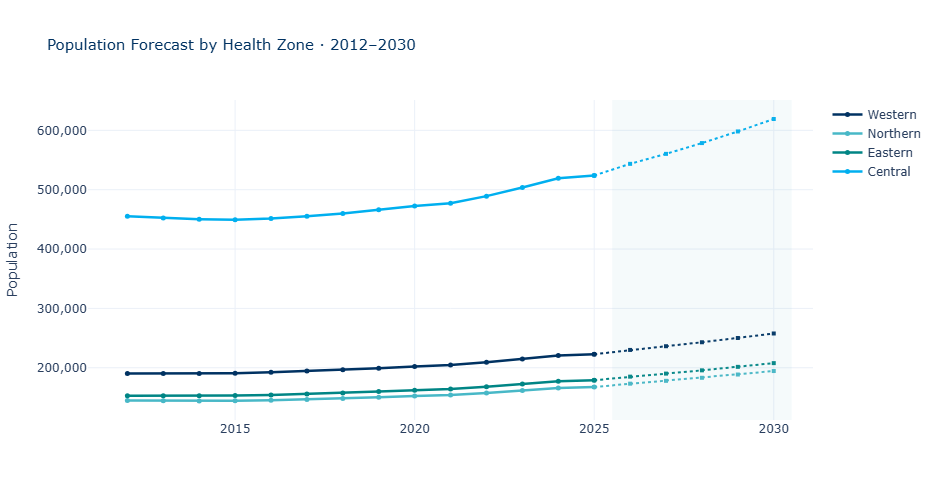

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# INTERACTIVE ZONE FORECAST — Plotly
# ══════════════════════════════════════════════════════════════════════════════

fig = go.Figure()
for zone in zones:
    zt = zone_totals_proj.loc[zone].sort_index()
    obs = zt[zt.index <= 2025]
    fcast = zt[zt.index >= 2025]
    
    fig.add_trace(go.Scatter(x=obs.index, y=obs.values, mode='lines+markers',
        name=zone, line=dict(color=ZONE_COLORS[zone], width=2.5),
        marker=dict(size=5), hovertemplate=f'{zone}<br>%{{x}}: %{{y:,}}<extra></extra>'))
    fig.add_trace(go.Scatter(x=fcast.index, y=fcast.values, mode='lines+markers',
        name=f'{zone} (proj)', line=dict(color=ZONE_COLORS[zone], width=2, dash='dot'),
        marker=dict(size=4, symbol='square'), showlegend=False,
        hovertemplate=f'{zone} proj<br>%{{x}}: %{{y:,}}<extra></extra>'))

fig.add_vrect(x0=2025.5, x1=2030.5, fillcolor=NS['slate_blue'], opacity=0.08, line_width=0)

fig.update_layout(
    title=dict(text='Population Forecast by Health Zone · 2012–2030',
               font=dict(size=15, color=NS['deep_blue'])),
    yaxis_title='Population', yaxis_tickformat=',',
    template='plotly_white', height=500, hovermode='x unified',
)
fig.show()

<div style="border-left: 4px solid #D30731; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**🔮 Projected Pyramids — 2021 vs 2030 Side by Side**

This is one of the most powerful visuals in the notebook. Each zone shows **two pyramids overlaid**:
- **Filled bars (semi-transparent)** = 2021 actual population
- **Outline bars** = 2030 projected population (blue outline = men, red outline = women)

**How was the 2030 projection built?**
We took each zone's 2021 census counts and multiplied them by a **growth factor** from the cohort projection. For example, if the NS-level 60–69 cohort grew by 15% from 2021→2030, then every zone's 60–69 band gets scaled up by 15%.

**What to look for:**
- **Where do the outlines extend beyond the filled bars?** Those age bands are growing.
- **Where are the outlines smaller than the fills?** Those bands are shrinking.
- Typically you'll see outlines **wider at the top** (more seniors in 2030) and **narrower at the bottom** (fewer children) — the hallmark of an aging population.
- The sex split (blue vs red outlines) shows whether men or women are driving the growth in each band.

</div>

**🔮 Projected Pyramids — 2021 vs 2030 Side by Side**

This is one of the most powerful visuals in the notebook. Each zone shows **two pyramids overlaid**:
- **Filled bars (semi-transparent)** = 2021 actual population (from Census)
- **Outline bars** = 2030 projected population (blue outline = M+, red outline = W+)

### How the 2030 Projection Was Built

We took each zone's 2021 Census counts and multiplied them by a **growth factor** derived from the NS-level cohort projection. For example, if the NS-level 60–69 cohort grew by 15% from 2021→2030 (polynomial model), then every zone's 60–69 band — both M+ and W+ — gets scaled up by that same 15%.

### What the Pyramids Show

**The red outlines (2030) extend beyond the filled bars (2021) in the 70–79 and 80+ bands across all four zones.** This is the most predictable demographic event in Nova Scotia — the baby boom cohort that was 60–69 in 2021 will be 70–79 by 2030. That upward shift is baked in; these people already exist.

**The outlines are narrower or equal at the bottom (0–19).** We held births constant (Option A — standard for ≤10 year health planning), so the children bands don't grow. The 10–19 band in 2030 is simply the 0–9 band from 2021 aged forward.

**Central's pyramid shape is visibly different** — wider in the 20–34 range because Halifax attracts young workers and international students. The 2030 outlines grow there too because the NS-level 20–29 cohort has been growing (immigration-driven), and Central holds ~47% of that cohort's share.

### ⚠️ Honest Limitation

The growth factor is applied **identically to M+ and W+** because the projection is built on combined-sex cohort totals — not gender-disaggregated trends. The pyramid shows M+ and W+ separately only because the 2021 Census baseline has that split. The 2030 outlines scale both by the same factor, meaning the **gender ratio in 2030 is assumed identical to 2021**. In reality, migration and mortality patterns differ by sex, so this ratio may shift — but we lack the sex-specific time series data to model that difference.

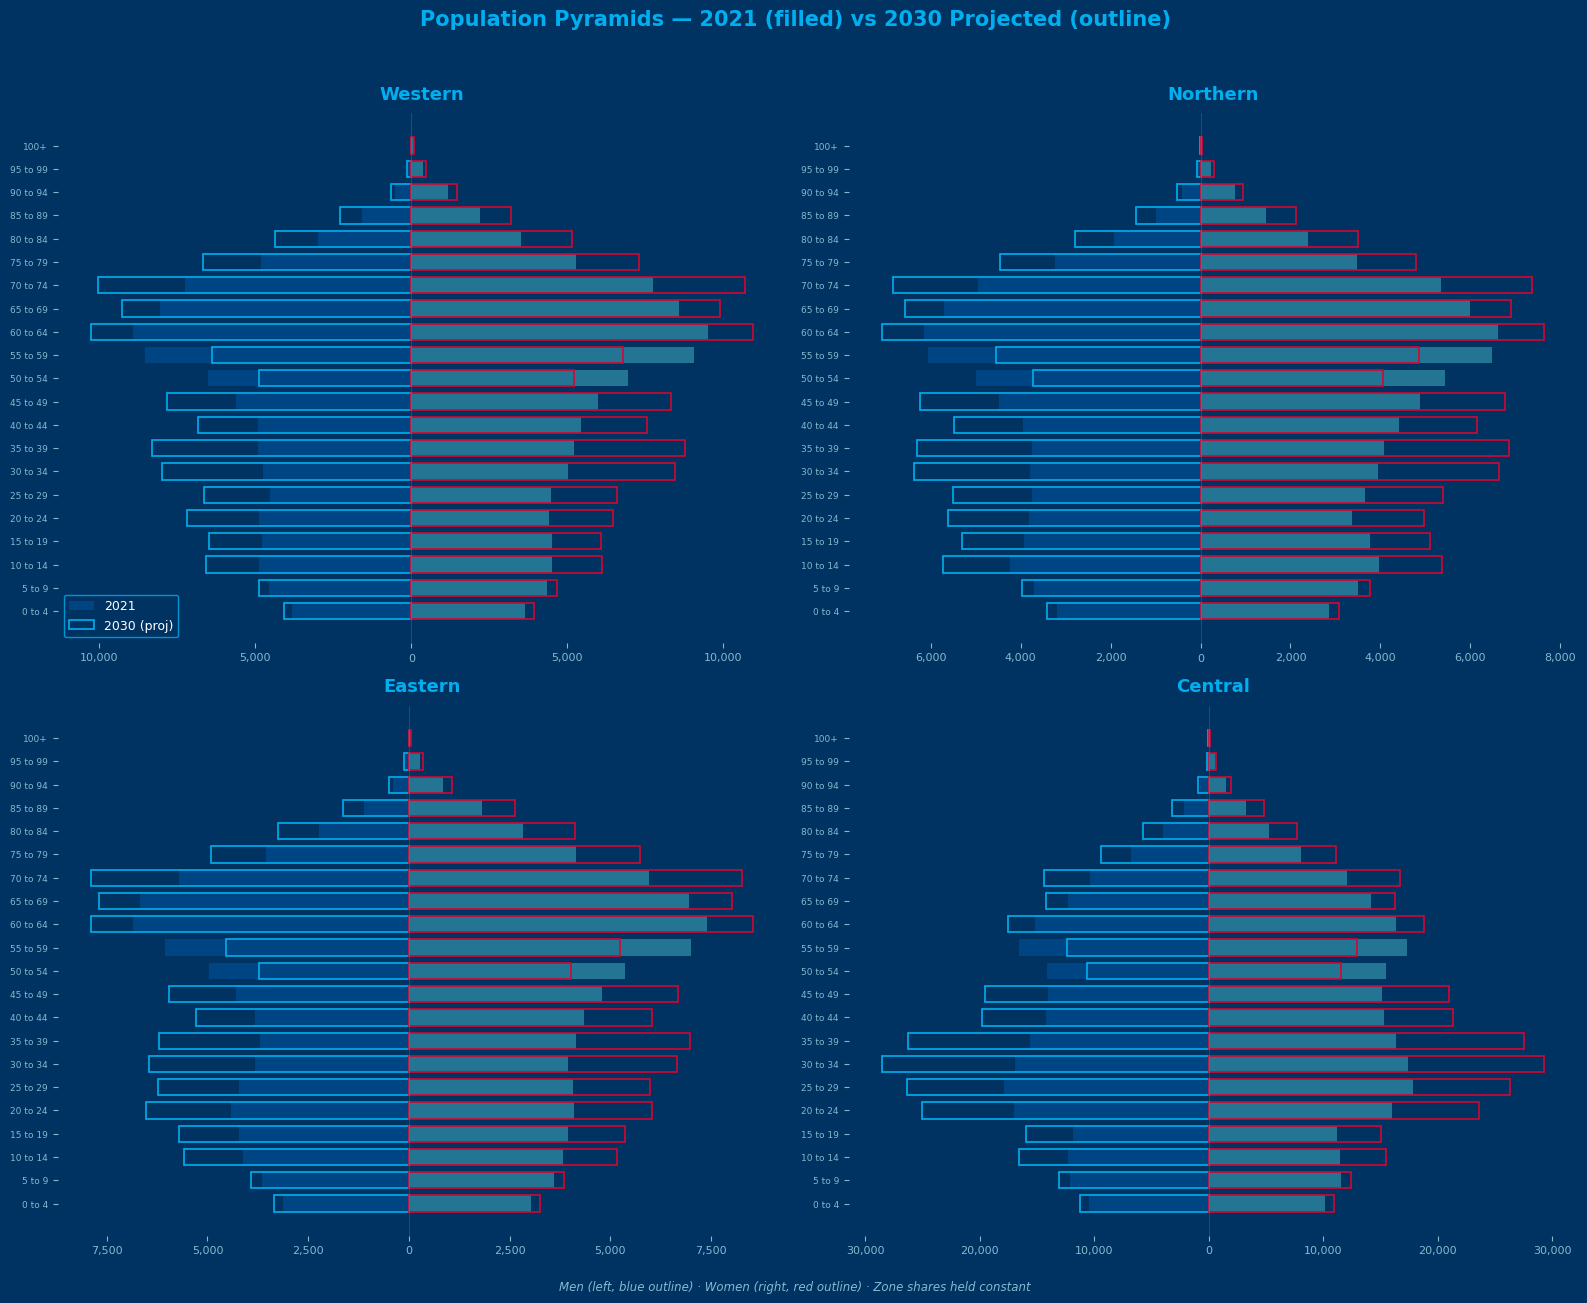

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# PROJECTED POPULATION PYRAMIDS — 2021 (filled) vs 2030 (outline)
# ══════════════════════════════════════════════════════════════════════════════

# We need zone-level cohort data for both years
# 2021: from census df
# 2030: from zf (zone_forecast)

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.patch.set_facecolor(NS['deep_blue'])

for ax, zone in zip(axes.flatten(), zones):
    ax.set_facecolor(NS['deep_blue'])
    
    # 2021 baseline from census
    zdf_21 = df[df['Health Zone Name'] == zone].sort_values('AgeMid')
    labels = zdf_21['Age Group'].str.replace(' years','').str.replace(' and over','+').values
    men_21 = zdf_21['Men'].values
    women_21 = zdf_21['Women'].values
    y_pos = np.arange(len(labels))
    
    # 2030 projection: need to map cohort totals back to 5-yr bands
    # Simplest approach: scale 2021 5-yr distribution by cohort growth factor
    zf_zone_21 = zf[(zf['Zone'] == zone) & (zf['Year'] == 2021)].set_index('Cohort')['Population']
    zf_zone_30 = zf[(zf['Zone'] == zone) & (zf['Year'] == 2030)].set_index('Cohort')['Population']
    
    growth_factors = {}
    for cohort in COHORT_ORDER:
        if cohort in zf_zone_21.index and zf_zone_21[cohort] > 0:
            growth_factors[cohort] = zf_zone_30.get(cohort, 0) / zf_zone_21[cohort]
        else:
            growth_factors[cohort] = 1.0
    
    men_30 = []
    women_30 = []
    for _, row in zdf_21.iterrows():
        cohort = CENSUS_TO_COHORT.get(row['Age Group'], None)
        gf = growth_factors.get(cohort, 1.0) if cohort else 1.0
        men_30.append(int(row['Men'] * gf))
        women_30.append(int(row['Women'] * gf))
    men_30 = np.array(men_30)
    women_30 = np.array(women_30)
    
    # Plot 2021 filled
    ax.barh(y_pos, -men_21, height=0.7, color=NS['scotia_blue'], alpha=0.5, edgecolor='none', label='2021')
    ax.barh(y_pos, women_21, height=0.7, color=NS['sea_green'], alpha=0.5, edgecolor='none')
    
    # Plot 2030 outline
    ax.barh(y_pos, -men_30, height=0.7, fill=False, edgecolor=NS['sky_blue'], linewidth=1.2, label='2030 (proj)')
    ax.barh(y_pos, women_30, height=0.7, fill=False, edgecolor=NS['crimson'], linewidth=1.2)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=6.5, color=NS['slate_blue'])
    ax.set_title(zone, color=NS['sky_blue'], fontsize=13, fontweight='bold', pad=10)
    ax.tick_params(axis='x', colors=NS['slate_blue'], labelsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{abs(int(x)):,}'))
    ax.axvline(0, color=NS['slate_blue'], linewidth=0.5, alpha=0.3)
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    if ax == axes.flatten()[0]:
        ax.legend(loc='lower left', fontsize=9,
                  facecolor=NS['deep_blue'], edgecolor=NS['sky_blue'],
                  labelcolor=NS['white'])

fig.suptitle('Population Pyramids — 2021 (filled) vs 2030 Projected (outline)',
             color=NS['sky_blue'], fontsize=15, fontweight='bold', y=0.99)
fig.text(0.5, 0.005,
         'Men (left, blue outline) · Women (right, red outline) · Zone shares held constant',
         ha='center', color=NS['slate_blue'], fontsize=8.5, style='italic')
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.savefig('pyramids_2021_vs_2030.png', dpi=180, bbox_inches='tight', facecolor=NS['deep_blue'])
plt.show()

---
### Key Findings

<div style="border-left: 4px solid #0058A4; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**Age Structure (2021 Census)**
1. **Central (Halifax)** has the youngest profile — highest working-age share, lowest dependency ratio
2. **All three rural zones** have an Aging Index exceeding 100 (more seniors than children)
3. The 55–74 bulge is pronounced in Western, Northern, and Eastern — these cohorts will shift into 65–84 by 2030

</div>

<div style="border-left: 4px solid #008585; padding: 10px 15px; margin: 10px 0; background-color: rgba(0,88,164,0.05); border-radius: 4px;">

**Population Projections (2026–2030)**
4. **NS is projected to exceed 1.15M by 2030** (polynomial model), driven by continued in-migration
5. **Senior cohorts (60–69, 70–79) are the fastest-growing** in absolute terms
6. **Youth cohorts (20–29) are also growing** — a reversal of the pre-2018 decline, reflecting international student and immigrant inflows
7. **Central absorbs ~47% of all growth** (by zone share), but rural zones also benefit from the provincial trend

</div>

<div style="border-left: 4px solid #D30731; padding: 10px 15px; margin: 10px 0; background-color: rgba(211,7,49,0.04); border-radius: 4px;">

⚠️ **Assumptions & Limitations**

- Zone distribution uses static 2021 Census shares — Central's actual share is likely growing faster
- Polynomial projections can overshoot — treat 2030 as a scenario, not a point forecast
- Migration patterns are policy-dependent and could shift
- **Health prevalence projections** (disease burden forecasting) are developed in a separate notebook

</div>